In [ ]:
!nvidia-smi

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Check if CUDA is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [4]:
# 1. Loading the dataset
data = load_breast_cancer()
X = data.data
y = data.target

In [5]:
# 2. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# 3. Standardizing the features (mean=0, variance=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
 #4. Converting NumPy arrays to PyTorch Tensors
# Note: CrossEntropyLoss expects target labels to be of type LongTensor
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Number of classes: {len(np.unique(y))}")

BATCH_SIZE = 32

Training data shape: torch.Size([455, 30])
Number of classes: 2


In [9]:
# Creatig TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders are ready!")

DataLoaders are ready!


In [10]:
class BreastCancerMultiClass(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(BreastCancerMultiClass, self).__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        # Output layer matches the number of classes
        self.output_layer = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        out = self.output_layer(x)
        return out

In [11]:
# Initialising model
input_dimension = X_train.shape[1] # 30 features
number_of_classes = 2 # 0 (Malignant) and 1 (Benign)

#  Moving the model to the CUDA device
model = BreastCancerMultiClass(input_dim=input_dimension, num_classes=number_of_classes).to(device)
print(model)

# CrossEntropyLoss is the standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

EPOCHS = 50
train_losses = []


BreastCancerMultiClass(
  (layer1): Linear(in_features=30, out_features=64, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)


In [12]:
for epoch in range(EPOCHS):
    model.train() # Set model to training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        # 1. Move data to GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # 2. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 3. Backward pass and optimization
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()       # Compute gradients
        optimizer.step()      # Update weights

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.4f}')

Epoch [10/50], Loss: 0.0579
Epoch [20/50], Loss: 0.0259
Epoch [30/50], Loss: 0.0124
Epoch [40/50], Loss: 0.0058
Epoch [50/50], Loss: 0.0029


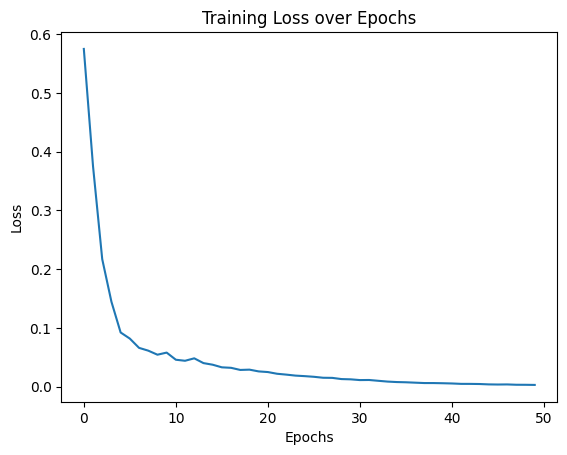

In [13]:
# Plot the training loss
plt.plot(train_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

model.eval() # Set model to evaluation mode (disables dropout/batchnorm updates)
correct = 0
total = 0


In [14]:
# Disabling gradient calculation for inference to save memory and compute
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move data to GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Get predictions
        outputs = model(inputs)

        # The class with the highest logit is our prediction
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the test data: {accuracy:.2f}%')

Accuracy of the model on the test data: 97.37%
